Loaded NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/exploratory_lomb_scargle_all_channels_FIXED_outputs.npz
Loaded summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/lomb_scargle_all_channels_FIXED_summary.csv
Channels: 32
Frequency bins: 1200


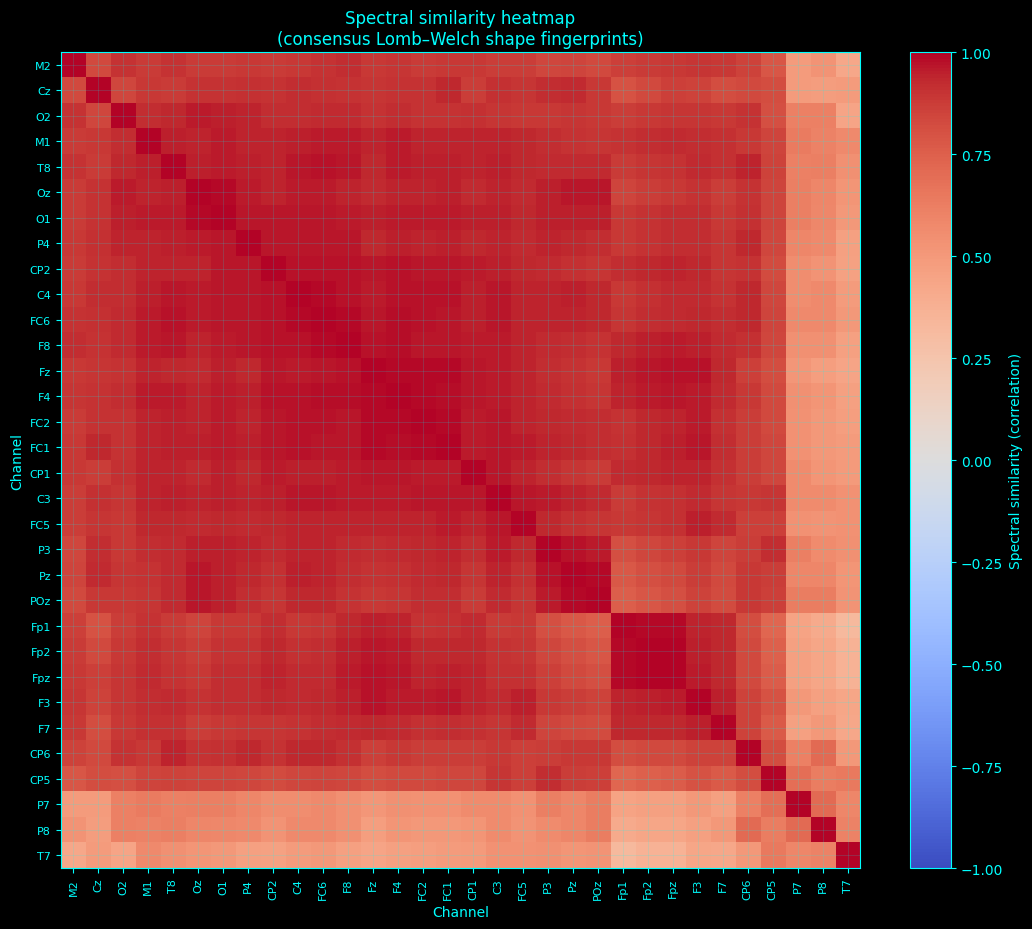

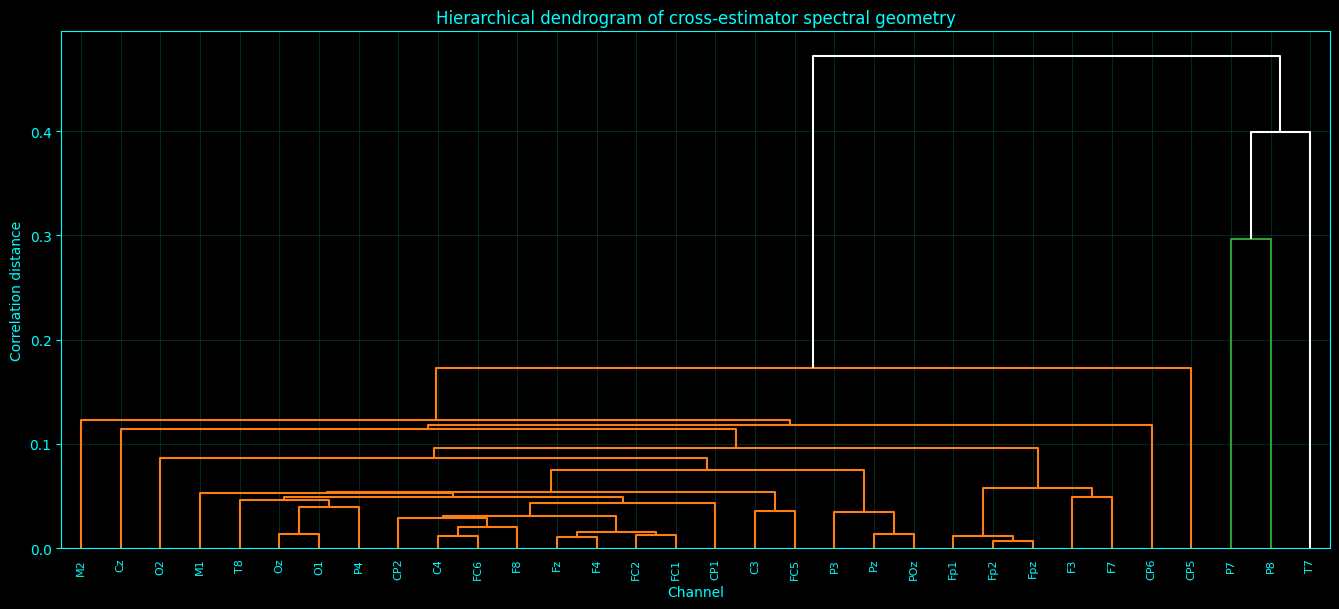

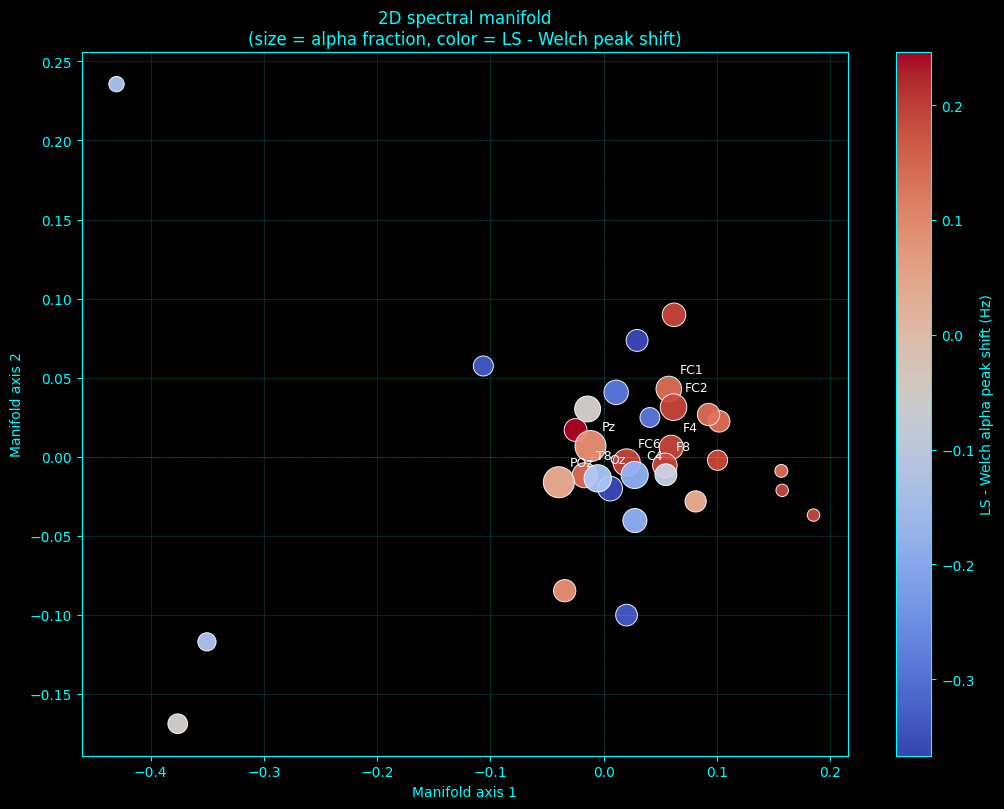

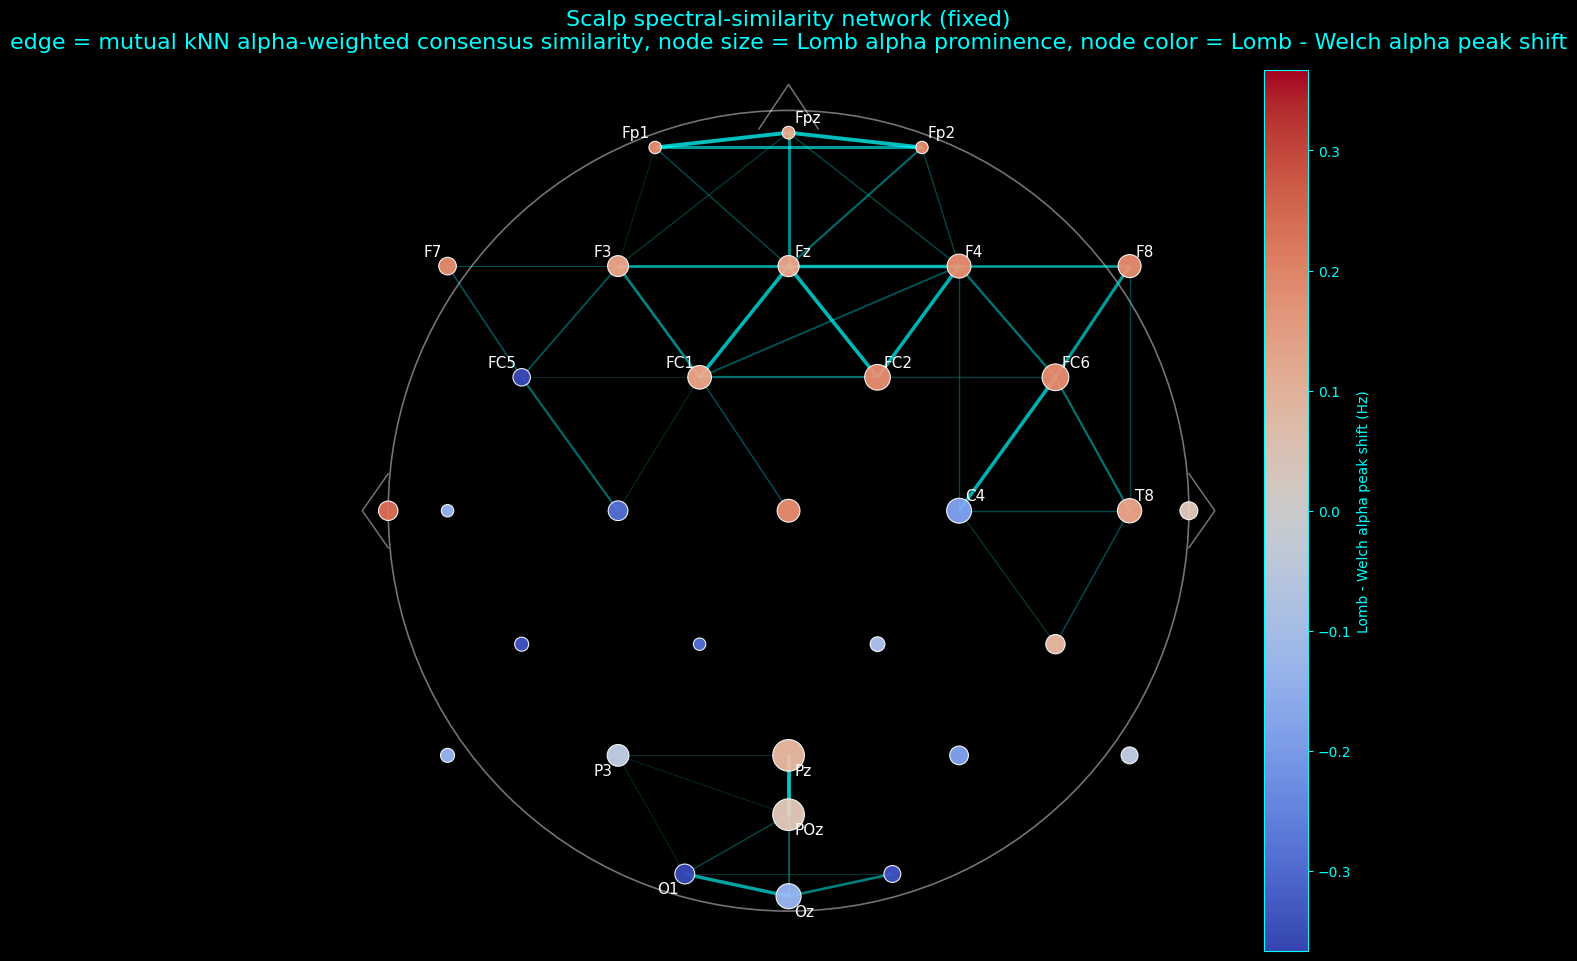


Saved geometry outputs:
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/spectral_geometry_outputs.npz
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/spectral_geometry_channel_metrics.csv

Saved plot files:
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/plots/13_clustered_spectral_similarity_heatmap.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/plots/14_spectral_geometry_dendrogram.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/plots/15_spectral_manifold_2d.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/plots/16_scalp_spectral_similarity_network_FIXE

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list, fcluster
from scipy.spatial.distance import squareform
from matplotlib.collections import LineCollection
from matplotlib import patches

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
results_dir = os.path.join(base_dir, "results", "exploratory_lomb_scargle_all_channels_FIXED")

npz_path = os.path.join(results_dir, "exploratory_lomb_scargle_all_channels_FIXED_outputs.npz")
summary_csv_path = os.path.join(results_dir, "lomb_scargle_all_channels_FIXED_summary.csv")

out_dir = os.path.join(results_dir, "spectral_geometry")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

fmin_compare, fmax_compare = 2.0, 45.0
n_clusters = 5
top_n_annotate = 10

eps = 1e-12
ACCENT = "cyan"
BG = "black"
GRID = ACCENT

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def robust_unit_interval(x, lo=5, hi=95):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    good = np.isfinite(x)
    if np.sum(good) < 3:
        return out
    a, b = np.nanpercentile(x[good], [lo, hi])
    span = max(b - a, eps)
    out[good] = np.clip((x[good] - a) / span, 0, 1)
    return out

def rowwise_standardize(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x, axis=1, keepdims=True)
    sd = np.nanstd(x, axis=1, keepdims=True)
    sd = np.where(~np.isfinite(sd) | (sd < eps), 1.0, sd)
    z = (x - mu) / sd
    z[~np.isfinite(z)] = 0.0
    return z

def finite_row_correlation_similarity(x):
    """
    Safe correlation-like similarity across rows.
    Uses cosine similarity of rowwise-zscored spectra.
    This avoids NaNs from zero-variance rows.
    """
    x = np.asarray(x, dtype=float)
    xz = rowwise_standardize(x)
    norms = np.linalg.norm(xz, axis=1, keepdims=True)
    xn = np.divide(xz, norms, out=np.zeros_like(xz), where=norms > eps)
    sim = xn @ xn.T
    sim = np.clip(sim, -1.0, 1.0)
    sim[~np.isfinite(sim)] = 0.0
    sim = 0.5 * (sim + sim.T)
    np.fill_diagonal(sim, 1.0)
    return sim

def classical_mds(distance_matrix, n_components=2):
    """
    Classical metric MDS / PCoA from a full square distance matrix.
    """
    D = np.asarray(distance_matrix, dtype=float)
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    pos = eigvals > 0
    eigvals = eigvals[pos]
    eigvecs = eigvecs[:, pos]

    if len(eigvals) == 0:
        return np.zeros((n, n_components)), np.zeros(n_components)

    k = min(n_components, len(eigvals))
    coords = eigvecs[:, :k] * np.sqrt(eigvals[:k])
    if k < n_components:
        coords = np.hstack([coords, np.zeros((n, n_components - k))])

    return coords, eigvals[:k]

def ensure_channel_by_freq(arr, n_channels, n_freqs, name):
    """
    Return array as [channels x freqs], accepting either orientation.
    """
    arr = np.asarray(arr, dtype=float)
    if arr.shape == (n_channels, n_freqs):
        return arr
    if arr.shape == (n_freqs, n_channels):
        return arr.T
    raise ValueError(
        f"{name} has unexpected shape {arr.shape}; "
        f"expected ({n_channels}, {n_freqs}) or ({n_freqs}, {n_channels})."
    )

def get_first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def robust_clip_symmetric(x, q=95):
    x = np.asarray(x, dtype=float)
    good = np.isfinite(x)
    if np.sum(good) == 0:
        return np.zeros_like(x), 1.0
    lim = np.nanpercentile(np.abs(x[good]), q)
    lim = max(float(lim), eps)
    return np.clip(x, -lim, lim), lim

def safe_log10(a):
    a = np.asarray(a, dtype=float)
    return np.log10(np.clip(a, eps, None))

def robust_minmax(x, qlo=5, qhi=95):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    good = np.isfinite(x)
    if np.sum(good) == 0:
        return out
    lo, hi = np.nanpercentile(x[good], [qlo, qhi])
    span = max(float(hi - lo), eps)
    out[good] = np.clip((x[good] - lo) / span, 0, 1)
    return out

def robust_scale(x, low=0.0, high=1.0, qlo=5, qhi=95):
    z = robust_minmax(x, qlo=qlo, qhi=qhi)
    return low + (high - low) * z

def head_positions_32():
    return {
        "Fp1": (-0.36, 0.98), "Fpz": (0.00, 1.02), "Fp2": (0.36, 0.98),
        "F7": (-0.92, 0.66), "F3": (-0.46, 0.66), "Fz": (0.00, 0.66), "F4": (0.46, 0.66), "F8": (0.92, 0.66),
        "FC5": (-0.72, 0.36), "FC1": (-0.24, 0.36), "FC2": (0.24, 0.36), "FC6": (0.72, 0.36),
        "M1": (-1.08, 0.00), "T7": (-0.92, 0.00), "C3": (-0.46, 0.00), "Cz": (0.00, 0.00), "C4": (0.46, 0.00), "T8": (0.92, 0.00), "M2": (1.08, 0.00),
        "CP5": (-0.72, -0.36), "CP1": (-0.24, -0.36), "CP2": (0.24, -0.36), "CP6": (0.72, -0.36),
        "P7": (-0.92, -0.66), "P3": (-0.46, -0.66), "Pz": (0.00, -0.66), "P4": (0.46, -0.66), "P8": (0.92, -0.66),
        "POz": (0.00, -0.82),
        "O1": (-0.28, -0.98), "Oz": (0.00, -1.04), "O2": (0.28, -0.98),
    }

def circular_fallback_positions(names):
    theta = np.linspace(0, 2 * np.pi, len(names), endpoint=False)
    return {ch: (np.cos(t), np.sin(t)) for ch, t in zip(names, theta)}

# -------------------------------------------------------
# LOAD SAVED OUTPUTS
# -------------------------------------------------------
if not os.path.exists(npz_path):
    raise FileNotFoundError(f"Missing NPZ: {npz_path}")
if not os.path.exists(summary_csv_path):
    raise FileNotFoundError(f"Missing summary CSV: {summary_csv_path}")

npz = np.load(npz_path, allow_pickle=True)
summary_df = pd.read_csv(summary_csv_path)

freqs_hz = np.asarray(npz["frequencies_hz"], dtype=float)
channel_names = [str(x) for x in np.asarray(npz["channel_names"]).tolist()]
n_channels = len(channel_names)
n_freqs = len(freqs_hz)

clean_lomb_raw = np.asarray(npz["clean_lomb_area_normalized_2_45Hz"], dtype=float)
clean_welch_raw = np.asarray(npz["clean_welch_area_normalized_2_45Hz"], dtype=float)

clean_lomb = ensure_channel_by_freq(clean_lomb_raw, n_channels, n_freqs, "clean_lomb")
clean_welch = ensure_channel_by_freq(clean_welch_raw, n_channels, n_freqs, "clean_welch")

if "display_lomb_smoothed" in npz.files:
    display_lomb_raw = np.asarray(npz["display_lomb_smoothed"], dtype=float)
    display_lomb = ensure_channel_by_freq(display_lomb_raw, n_channels, n_freqs, "display_lomb_smoothed")
else:
    display_lomb = clean_lomb.copy()

if "display_welch_smoothed" in npz.files:
    display_welch_raw = np.asarray(npz["display_welch_smoothed"], dtype=float)
    display_welch = ensure_channel_by_freq(display_welch_raw, n_channels, n_freqs, "display_welch_smoothed")
else:
    display_welch = clean_welch.copy()

summary_df = summary_df.set_index("channel").reindex(channel_names).reset_index()

print(f"Loaded NPZ: {npz_path}")
print(f"Loaded summary CSV: {summary_csv_path}")
print(f"Channels: {len(channel_names)}")
print(f"Frequency bins: {len(freqs_hz)}")

# -------------------------------------------------------
# BUILD CONSENSUS SPECTRAL FINGERPRINTS
# -------------------------------------------------------
compare_mask = (freqs_hz >= fmin_compare) & (freqs_hz <= fmax_compare)

# Channel x frequency matrices
X_lomb = safe_log10(display_lomb[:, compare_mask])
X_welch = safe_log10(display_welch[:, compare_mask])

# Standardize each channel across frequency to emphasize shape
X_lomb_z = rowwise_standardize(X_lomb)
X_welch_z = rowwise_standardize(X_welch)

# Consensus fingerprint
X_consensus = 0.5 * (X_lomb_z + X_welch_z)
X_consensus[~np.isfinite(X_consensus)] = 0.0

# SAFE similarity + distance
similarity = finite_row_correlation_similarity(X_consensus)
distance = 1.0 - similarity
distance[~np.isfinite(distance)] = 1.0
distance = np.clip(distance, 0.0, 2.0)
distance = 0.5 * (distance + distance.T)
np.fill_diagonal(distance, 0.0)

# SAFE linkage input
condensed_dist = squareform(distance, checks=False)
if not np.all(np.isfinite(condensed_dist)):
    condensed_dist = np.where(np.isfinite(condensed_dist), condensed_dist, 1.0)

Z = linkage(condensed_dist, method="average", optimal_ordering=True)
leaf_order = leaves_list(Z)
cluster_ids = fcluster(Z, t=min(n_clusters, n_channels), criterion="maxclust")

# Summary-aligned descriptors
alpha_prom_col = get_first_existing_column(summary_df, [
    "lomb_alpha_peak_prominence",
    "lomb_alpha_peak_prom",
    "lomb_peak_prominence_alpha",
])
alpha_frac_col = get_first_existing_column(summary_df, [
    "lomb_alpha_band_fraction_2_45Hz",
    "alpha_band_fraction_2_45Hz",
    "lomb_alpha_fraction",
])
peak_shift_col = get_first_existing_column(summary_df, [
    "alpha_peak_shift_signed_Hz",
    "ls_minus_welch_alpha_peak_shift_hz",
    "lomb_minus_welch_alpha_peak_shift_hz",
])

alpha_prom = pd.to_numeric(summary_df[alpha_prom_col], errors="coerce").values.astype(float) if alpha_prom_col else np.zeros(n_channels)
alpha_frac = pd.to_numeric(summary_df[alpha_frac_col], errors="coerce").values.astype(float) if alpha_frac_col else np.zeros(n_channels)
peak_shift = pd.to_numeric(summary_df[peak_shift_col], errors="coerce").values.astype(float) if peak_shift_col else np.zeros(n_channels)

prom_norm = robust_unit_interval(alpha_prom, lo=5, hi=95)
frac_norm = robust_unit_interval(alpha_frac, lo=5, hi=95)

# -------------------------------------------------------
# SAVE NUMERIC GEOMETRY OUTPUTS
# -------------------------------------------------------
geometry_csv_path = os.path.join(out_dir, "spectral_geometry_channel_metrics.csv")
geometry_df = pd.DataFrame({
    "channel": channel_names,
    "cluster_id": cluster_ids,
    "alpha_prominence": alpha_prom,
    "alpha_fraction": alpha_frac,
    "peak_shift_signed_hz": peak_shift,
})
geometry_df.to_csv(geometry_csv_path, index=False)

similarity_npz_path = os.path.join(out_dir, "spectral_geometry_outputs.npz")
np.savez_compressed(
    similarity_npz_path,
    channel_names=np.array(channel_names, dtype=object),
    frequencies_hz=freqs_hz[compare_mask],
    consensus_fingerprints=X_consensus,
    similarity_matrix=similarity,
    distance_matrix=distance,
    cluster_ids=cluster_ids,
    leaf_order=leaf_order,
)

# -------------------------------------------------------
# PLOT 13 — CLUSTERED SPECTRAL SIMILARITY HEATMAP
# -------------------------------------------------------
ordered_channels = [channel_names[i] for i in leaf_order]
ordered_similarity = similarity[np.ix_(leaf_order, leaf_order)]

fig, ax = plt.subplots(figsize=(10.8, 9.4), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    ordered_similarity,
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    interpolation="nearest",
    aspect="auto",
)

ax.set_title("Spectral similarity heatmap\n(consensus Lomb–Welch shape fingerprints)")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(ordered_channels)))
ax.set_xticklabels(ordered_channels, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(ordered_channels)))
ax.set_yticklabels(ordered_channels, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Spectral similarity (correlation)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot13_path = os.path.join(plots_dir, "13_clustered_spectral_similarity_heatmap.png")
plt.tight_layout()
plt.savefig(plot13_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 14 — DENDROGRAM
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(13.5, 6.2), facecolor=BG)
style_ax(ax)

dendrogram(
    Z,
    labels=channel_names,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
    color_threshold=None,
    above_threshold_color="white",
)

ax.set_title("Hierarchical dendrogram of cross-estimator spectral geometry")
ax.set_xlabel("Channel")
ax.set_ylabel("Correlation distance")

plot14_path = os.path.join(plots_dir, "14_spectral_geometry_dendrogram.png")
plt.tight_layout()
plt.savefig(plot14_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 15 — 2D SPECTRAL MANIFOLD
# -------------------------------------------------------
coords, eigvals = classical_mds(distance, n_components=2)
x = coords[:, 0]
y = coords[:, 1]

shift_good = np.isfinite(peak_shift)
if np.sum(shift_good) >= 3:
    shift_abs = np.nanpercentile(np.abs(peak_shift[shift_good]), 95)
else:
    shift_abs = 0.5
shift_abs = max(float(shift_abs), 0.25)

sizes = 80 + 420 * frac_norm

fig, ax = plt.subplots(figsize=(10.6, 8.2), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    x,
    y,
    s=sizes,
    c=np.clip(peak_shift, -shift_abs, shift_abs),
    cmap="coolwarm",
    alpha=0.92,
    edgecolors="white",
    linewidths=0.7,
)

annot_idx = np.argsort(-np.nan_to_num(alpha_prom, nan=-np.inf))[:top_n_annotate]
for idx in annot_idx:
    ax.text(
        x[idx] + 0.01,
        y[idx] + 0.01,
        channel_names[idx],
        color="white",
        fontsize=9,
    )

ax.axhline(0.0, color="white", alpha=0.18, linewidth=0.8, linestyle=":")
ax.axvline(0.0, color="white", alpha=0.18, linewidth=0.8, linestyle=":")
ax.set_title("2D spectral manifold\n(size = alpha fraction, color = LS - Welch peak shift)")
ax.set_xlabel("Manifold axis 1")
ax.set_ylabel("Manifold axis 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("LS - Welch alpha peak shift (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot15_path = os.path.join(plots_dir, "15_spectral_manifold_2d.png")
plt.tight_layout()
plt.savefig(plot15_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 16 — FIXED SCALP SPECTRAL-SIMILARITY NETWORK
# mutual kNN graph on alpha-weighted consensus spectral similarity
# edge = strongest consensus similarity
# node size = Lomb alpha prominence
# node color = Lomb - Welch alpha peak shift
# -------------------------------------------------------
summary = summary_df.copy()
summary = summary.set_index("channel", drop=False)

prom_col = get_first_existing_column(summary, [
    "lomb_alpha_peak_prominence",
    "lomb_alpha_peak_prom",
    "lomb_peak_prominence_alpha",
    "alpha_peak_prominence_lomb",
])

lomb_peak_col = get_first_existing_column(summary, [
    "lomb_alpha_peak_hz",
    "lomb_alpha_peak_freq_hz",
    "lomb_alpha_peak_frequency_hz",
    "lomb_alpha_peak_frequency_Hz",
])

welch_peak_col = get_first_existing_column(summary, [
    "welch_alpha_peak_hz",
    "welch_alpha_peak_freq_hz",
    "welch_alpha_peak_frequency_hz",
    "welch_alpha_peak_frequency_Hz",
])

shift_col = get_first_existing_column(summary, [
    "ls_minus_welch_alpha_peak_shift_hz",
    "lomb_minus_welch_alpha_peak_shift_hz",
    "alpha_peak_shift_hz",
    "alpha_peak_shift_signed_Hz",
])

alpha_prom_net = np.full(n_channels, np.nan, dtype=float)
peak_shift_net = np.full(n_channels, np.nan, dtype=float)

for i, ch in enumerate(channel_names):
    if ch not in summary.index:
        continue

    if prom_col is not None:
        alpha_prom_net[i] = pd.to_numeric(summary.at[ch, prom_col], errors="coerce")

    if shift_col is not None:
        peak_shift_net[i] = pd.to_numeric(summary.at[ch, shift_col], errors="coerce")
    elif lomb_peak_col is not None and welch_peak_col is not None:
        lp = pd.to_numeric(summary.at[ch, lomb_peak_col], errors="coerce")
        wp = pd.to_numeric(summary.at[ch, welch_peak_col], errors="coerce")
        if np.isfinite(lp) and np.isfinite(wp):
            peak_shift_net[i] = lp - wp

if np.any(np.isfinite(alpha_prom_net)):
    alpha_prom_net = np.where(np.isfinite(alpha_prom_net), alpha_prom_net, np.nanmedian(alpha_prom_net[np.isfinite(alpha_prom_net)]))
else:
    alpha_prom_net = np.zeros(n_channels)

peak_shift_net = np.where(np.isfinite(peak_shift_net), peak_shift_net, 0.0)

full_mask = (freqs_hz >= 2.0) & (freqs_hz <= 45.0)
alpha_mask = (freqs_hz >= 8.0) & (freqs_hz <= 13.0)

log_lomb = safe_log10(clean_lomb)
log_welch = safe_log10(clean_welch)

full_lomb_corr = finite_row_correlation_similarity(log_lomb[:, full_mask])
full_welch_corr = finite_row_correlation_similarity(log_welch[:, full_mask])

if np.sum(alpha_mask) >= 3:
    alpha_lomb_corr = finite_row_correlation_similarity(log_lomb[:, alpha_mask])
    alpha_welch_corr = finite_row_correlation_similarity(log_welch[:, alpha_mask])
else:
    alpha_lomb_corr = full_lomb_corr.copy()
    alpha_welch_corr = full_welch_corr.copy()

consensus_sim = (
    0.30 * full_lomb_corr +
    0.30 * full_welch_corr +
    0.20 * alpha_lomb_corr +
    0.20 * alpha_welch_corr
)
consensus_sim = np.asarray(consensus_sim, dtype=float)
consensus_sim[~np.isfinite(consensus_sim)] = 0.0
consensus_sim = 0.5 * (consensus_sim + consensus_sim.T)
np.fill_diagonal(consensus_sim, 1.0)

sim_no_diag = consensus_sim.copy()
np.fill_diagonal(sim_no_diag, -np.inf)

k = 4
nbrs = np.argsort(sim_no_diag, axis=1)[:, ::-1][:, :k]

finite_edge_vals = sim_no_diag[np.isfinite(sim_no_diag)]
global_edge_floor = np.nanpercentile(finite_edge_vals, 82) if finite_edge_vals.size else 0.0

edge_set = set()
for i in range(n_channels):
    for j in nbrs[i]:
        if j < 0:
            continue
        mutual = i in nbrs[j]
        strong = consensus_sim[i, j] >= global_edge_floor
        if mutual or strong:
            a, b = sorted((int(i), int(j)))
            if a != b:
                edge_set.add((a, b))

edges = sorted(list(edge_set))
edge_weights = np.array([consensus_sim[i, j] for i, j in edges], dtype=float) if edges else np.array([])

if edge_weights.size > 0:
    keep_floor = np.nanpercentile(edge_weights, 25)
    edges = [e for e, w in zip(edges, edge_weights) if w >= keep_floor]
    edge_weights = np.array([consensus_sim[i, j] for i, j in edges], dtype=float)

degree = np.zeros(n_channels, dtype=int)
for i, j in edges:
    degree[i] += 1
    degree[j] += 1

pos_map = head_positions_32()
fallback = circular_fallback_positions(channel_names)
xy = np.array([pos_map.get(ch, fallback[ch]) for ch in channel_names], dtype=float)

node_sizes = robust_scale(alpha_prom_net, low=80, high=520, qlo=10, qhi=95)
peak_shift_clip, shift_lim = robust_clip_symmetric(peak_shift_net, q=95)
node_cmap = plt.cm.coolwarm
node_norm = plt.Normalize(vmin=-shift_lim, vmax=shift_lim)

if edge_weights.size > 0:
    ew = robust_scale(edge_weights, low=0.6, high=2.8, qlo=10, qhi=95)
    ea = robust_scale(edge_weights, low=0.18, high=0.75, qlo=10, qhi=95)
else:
    ew = np.array([])
    ea = np.array([])

prom_rank = np.argsort(np.argsort(-alpha_prom_net))
label_mask = (prom_rank < 8) | (degree >= 3)

fig, ax = plt.subplots(figsize=(10.5, 10.5), facecolor=BG)
style_ax(ax)

head = patches.Circle((0, 0), radius=1.08, fill=False, ec="white", lw=1.2, alpha=0.45)
ax.add_patch(head)

ax.plot([-0.08, 0.00, 0.08], [1.03, 1.15, 1.03], color="white", lw=1.1, alpha=0.45)
ax.plot([-1.08, -1.15, -1.08], [0.10, 0.00, -0.10], color="white", lw=1.1, alpha=0.45)
ax.plot([1.08, 1.15, 1.08], [0.10, 0.00, -0.10], color="white", lw=1.1, alpha=0.45)

if edges:
    segs = []
    colors = []
    widths = []
    for idx, (i, j) in enumerate(edges):
        segs.append([xy[i], xy[j]])
        colors.append((0.0, 1.0, 1.0, float(ea[idx])))
        widths.append(float(ew[idx]))
    lc = LineCollection(segs, colors=colors, linewidths=widths, zorder=1)
    ax.add_collection(lc)

sc = ax.scatter(
    xy[:, 0], xy[:, 1],
    s=node_sizes,
    c=peak_shift_clip,
    cmap=node_cmap,
    norm=node_norm,
    edgecolors="white",
    linewidths=0.8,
    alpha=0.92,
    zorder=3
)

for i, ch in enumerate(channel_names):
    if not label_mask[i]:
        continue
    dx = 0.015 if xy[i, 0] >= 0 else -0.015
    dy = 0.020 if xy[i, 1] >= 0 else -0.020
    ha = "left" if dx > 0 else "right"
    va = "bottom" if dy > 0 else "top"
    ax.text(
        xy[i, 0] + dx,
        xy[i, 1] + dy,
        ch,
        color="white",
        fontsize=11,
        ha=ha,
        va=va,
        zorder=4
    )

ax.set_aspect("equal")
ax.set_xlim(-1.18, 1.18)
ax.set_ylim(-1.18, 1.18)
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)

ax.set_title(
    "Scalp spectral-similarity network (fixed)\n"
    "edge = mutual kNN alpha-weighted consensus similarity, "
    "node size = Lomb alpha prominence, node color = Lomb - Welch alpha peak shift",
    color=ACCENT,
    fontsize=16,
    pad=18
)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Lomb - Welch alpha peak shift (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for lab in cbar.ax.get_yticklabels():
    lab.set_color(ACCENT)

plot16_path = os.path.join(plots_dir, "16_scalp_spectral_similarity_network_FIXED.png")
plt.tight_layout()
plt.savefig(plot16_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# FINAL PRINTS
# -------------------------------------------------------
print("\nSaved geometry outputs:")
print(similarity_npz_path)
print(geometry_csv_path)

print("\nSaved plot files:")
print(plot13_path)
print(plot14_path)
print(plot15_path)
print(plot16_path)

print("\nDone.")

# Wavelet Transform

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This scholarly overview elucidates the computational pipeline for frequency decomposition of electroencephalogram (EEG) data using wavelet transform. The technique provides an alternative to Fourier-based methods and allows for time-frequency localization.</p>
        <h2>Objectives</h2>
        <ul>
            <li>Channel-based Data Selection: Individual EEG channels are parsed from the master dataset.</li>
            <li>Continuous Wavelet Transform: Application of the wavelet transform to the EEG data.</li>
            <li>Power Spectral Density Estimation: Deriving PSD from the wavelet coefficients.</li>
            <li>Visualization: Time-frequency representation of the wavelet-based PSD.</li>
        </ul>
        <h2>Mathematical Foundations</h2>
        <h3>Wavelet Transform</h3>
        <p>The Continuous Wavelet Transform (CWT) is mathematically formulated as:</p>
        \[ CWT(x, a, b) = \frac{1}{\sqrt{a}} \int x(t) \psi^*\left(\frac{t-b}{a}\right)dt \]
        <p>Where \( \psi(t) \) is the mother wavelet and \( a \) and \( b \) are the scale and translation parameters respectively.</p>
        <h3>Power Spectral Density (PSD)</h3>
        <p>PSD is derived from the wavelet coefficients as:</p>
        \[ \text{PSD} = | \text{coefficients} |^2 \]
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Computational Steps</h2>
        <p>Each EEG channel undergoes the following computational steps:</p>
        <ul>
            <li>EEG data for the channel is extracted.</li>
            <li>Wavelet transform is applied to the EEG data using the Morlet wavelet.</li>
            <li>PSD is calculated from the absolute square of the wavelet coefficients.</li>
        </ul>
        <h2>Data Visualization</h2>
        <p>Frequency decomposition is visualized as an image plot. The x-axis represents time, while the y-axis represents frequency. The colors indicate the magnitude of the PSD at each time-frequency point, following the 'inferno' colormap for better visual discrimination.</p>
        <h2>Data Serialization</h2>
        <p>PSD values are saved as a NumPy file, adhering to a specified directory path. This ensures easy retrieval for subsequent analyses or publications.</p>
        <h2>Scientific Implications</h2>
        <p>Wavelet-based methods for time-frequency analysis offer finer granularity and are particularly advantageous for non-stationary signals like EEG. This approach is pivotal for neuroscientific studies related to brain oscillations, event-related potentials, and cognitive states.</p>
    </div>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>
